# Item-Level Descriptives EDA (Authors vs Foils)

Input dataset:
- `data/stepwise_cleaned_versions/03_participant_demographics_normalized_categories/ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories.csv`

Goals:
1. Print all author items and all foil items separately (quick cleaning audit)
2. Compute item-level descriptives:
   - item type (author vs foil)
   - endorsement proportion (`p`)
   - missing rate
   - corrected item-total correlation for author items
   - for foil items: correlation with participant corrected score and with false-alarm tendency
3. Apply pragmatic flag thresholds (for review, not auto-deletion):
   - endorsement `< .05` or `> .95`
   - corrected item-total `< .10` or negative (authors)
   - foil endorsement clearly above foil pool (95th percentile)
   - very high missingness
4. Plot author genre distribution (counts and endorsement profile)

Why this pass matters:
- Very low endorsement for authors can indicate overly difficult or culturally obsolete items
- Very high endorsement for authors can indicate overly easy items
- Near-zero/negative corrected item-total can indicate dysfunctional items
- High foil endorsement can indicate guessing or weak distractors
- In line with Moore & Gordon logic, difficult items and foil behavior can co-cluster and should be screened descriptively

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)

In [2]:
PROJECT_ROOT = Path("..").resolve().parent
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "stepwise_cleaned_versions"
    / "03_participant_demographics_normalized_categories"
    / "ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories.csv"
)

raw = pd.read_csv(DATA_PATH, header=None)
labels = raw.iloc[0].fillna("").astype(str)
codes = raw.iloc[1].fillna("").astype(str)
responses = raw.iloc[2:, :].reset_index(drop=True)

print(f"Loaded: {DATA_PATH}")
print(f"Rows (participants): {len(responses)}")
print(f"Columns (full width): {raw.shape[1]}")

Loaded: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/03_participant_demographics_normalized_categories/ART_pretest_(for Castano)_EN__participant_demographics_step04_normalized_categories.csv
Rows (participants): 908
Columns (full width): 216


In [3]:
def normalize_code(code: str) -> str:
    return re.sub(r"\s+", "", str(code).strip().lower())


ITEM_CODE_PATTERN = re.compile(r"^(fill\d+|(?:mod|cla|sci|det|fan|soc)\d+)$")

code_norm = codes.map(normalize_code)
item_mask = code_norm.map(lambda x: bool(ITEM_CODE_PATTERN.match(x)))
item_indices = np.flatnonzero(item_mask.to_numpy())

item_labels = labels.iloc[item_indices].astype(str).str.strip().reset_index(drop=True)
item_codes = codes.iloc[item_indices].astype(str).str.strip().reset_index(drop=True)
item_codes_norm = code_norm.iloc[item_indices].reset_index(drop=True)

item_type = np.where(item_codes_norm.str.startswith("fill"), "foil", "author")
item_genre_prefix = item_codes_norm.str.extract(r"^([a-z]+)", expand=False).fillna("")

genre_map = {
    "cla": "Classics",
    "mod": "Modern/Literary",
    "sci": "Sci-Fi",
    "det": "Detective/Thriller",
    "fan": "Fantasy",
    "soc": "Social/Other",
}
item_genre = [genre_map.get(prefix, "Foil") if itype == "author" else "Foil" for prefix, itype in zip(item_genre_prefix, item_type)]

item_meta = pd.DataFrame(
    {
        "item_idx": item_indices,
        "item_label": item_labels,
        "item_code": item_codes,
        "item_code_norm": item_codes_norm,
        "item_type": item_type,
        "genre": item_genre,
    }
)

# Make an always-unique key because some codes are duplicated (for example, repeated fill numbers).
item_meta["item_id"] = [f"{code}__{i:03d}" for i, code in enumerate(item_meta["item_code_norm"]) ]

item_resp = responses.iloc[:, item_indices].apply(pd.to_numeric, errors="coerce")
item_resp = item_resp.where(item_resp.isin([0, 1]))
item_resp.columns = item_meta["item_id"].tolist()

print(f"Detected item columns: {len(item_indices)}")
print(item_meta["item_type"].value_counts().to_string())

Detected item columns: 207
item_type
foil      107
author    100


## 0) Cleaning audit: print all author and foil items separately

In [4]:
authors_list = item_meta.loc[item_meta["item_type"] == "author", ["item_id", "item_code_norm", "item_label", "genre"]].copy()
foils_list = item_meta.loc[item_meta["item_type"] == "foil", ["item_id", "item_code_norm", "item_label"]].copy()

print(f"Author items: {len(authors_list)}")
display(authors_list.reset_index(drop=True))

print(f"Foil items: {len(foils_list)}")
display(foils_list.reset_index(drop=True))

Author items: 100


,item_id,item_code_norm,item_label,genre
0,mod1__001,mod1,Khaled Hosseini,Modern/Literary
1,mod2__002,mod2,Donna Tartt,Modern/Literary
2,cla1__004,cla1,Archibald Cronin,Classics
3,det1__005,det1,Gillian Flynn,Detective/Thriller
4,cla2__011,cla2,Gabriel Garsia Marquez,Classics
5,cla3__012,cla3,James Fenimore Cooper,Classics
6,cla4__013,cla4,Henryk Sienkiewicz,Classics
7,det2__015,det2,Paula Hawkins,Detective/Thriller
8,sci1__016,sci1,George Orwell,Sci-Fi
9,cla6__017,cla6,Jane Austen,Classics


Foil items: 107


,item_id,item_code_norm,item_label
0,fill1__000,fill1,Gerrit HoogenbuM fill1
1,fill2__003,fill2,Gonzalo Hervas fill2
2,fill3__006,fill3,Richard Gould fill3
3,fill4__007,fill4,Brian Callis fill4
4,fill5__008,fill5,Petr Sabluk fill5
5,fill6__009,fill6,Neil Bourke fill6
6,fill7__010,fill7,Chris Reynolds fill7
7,fill8__014,fill8,Paul Merwick fill8
8,fill9__019,fill9,Secundino Lopez fill9
9,fill10__020,fill10,Vladimir Sidorenko fill 10


## 1) Participant-level helper scores (for foil diagnostics)

In [5]:
author_codes = item_meta.loc[item_meta["item_type"] == "author", "item_id"].tolist()
foil_codes = item_meta.loc[item_meta["item_type"] == "foil", "item_id"].tolist()

author_resp = item_resp[author_codes]
foil_resp = item_resp[foil_codes]

hits = author_resp.sum(axis=1, skipna=True)
false_alarms = foil_resp.sum(axis=1, skipna=True)

n_foil_answered = foil_resp.notna().sum(axis=1).replace(0, np.nan)
foil_tendency = false_alarms / n_foil_answered

corrected_score = hits - false_alarms

participant_scores = pd.DataFrame(
    {
        "hits": hits,
        "false_alarms": false_alarms,
        "n_foil_answered": n_foil_answered,
        "foil_tendency": foil_tendency,
        "corrected_score": corrected_score,
    }
)

display(participant_scores.describe(percentiles=[0.05, 0.5, 0.95]).T)

,count,mean,std,min,5%,50%,95%,max
hits,908.0,53.105727,20.096346,11.0,21.0,53.000000,84.000000,98.000000
false_alarms,908.0,3.843612,5.015059,0.0,0.0,2.000000,14.000000,31.000000
n_foil_answered,908.0,104.998899,0.033186,104.0,105.0,105.000000,105.000000,105.000000
foil_tendency,908.0,0.036606,0.047762,0.0,0.0,0.019048,0.133333,0.295238
corrected_score,908.0,49.262115,20.002250,9.0,17.0,49.500000,81.000000,97.000000


## 2) Item-level descriptives and requested correlations

In [6]:
rows = []

total_author = author_resp.sum(axis=1, skipna=True)

for _, meta in item_meta.iterrows():
    item_id = meta["item_id"]
    x = item_resp[item_id]

    endorsement_rate = x.mean(skipna=True)
    missing_rate = x.isna().mean()

    row = {
        "item_id": item_id,
        "item_code_norm": meta["item_code_norm"],
        "item_label": meta["item_label"],
        "item_code_raw": meta["item_code"],
        "item_type": meta["item_type"],
        "genre": meta["genre"],
        "endorsement_rate": endorsement_rate,
        "missing_rate": missing_rate,
        "author_corrected_item_total_r": np.nan,
        "foil_corr_with_corrected_score": np.nan,
        "foil_corr_with_fa_tendency": np.nan,
    }

    if meta["item_type"] == "author":
        # Corrected item-total for author item: correlate item with total author score excluding the item itself.
        corrected_total = total_author - x.fillna(0)
        row["author_corrected_item_total_r"] = x.corr(corrected_total)
    else:
        row["foil_corr_with_corrected_score"] = x.corr(corrected_score)
        row["foil_corr_with_fa_tendency"] = x.corr(foil_tendency)

    rows.append(row)

item_stats = pd.DataFrame(rows)

item_stats = item_stats.sort_values(
    by=["item_type", "genre", "endorsement_rate"],
    ascending=[True, True, True],
).reset_index(drop=True)

display(item_stats.head(20))

/home/polina/.local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/polina/.local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,item_id,item_code_norm,item_label,item_code_raw,item_type,genre,endorsement_rate,missing_rate,author_corrected_item_total_r,foil_corr_with_corrected_score,foil_corr_with_fa_tendency
0,cla1__004,cla1,Archibald Cronin,cla1,author,Classics,0.142070,0.0,0.410814,NaN,NaN
1,cla25__187,cla25,Lawrense Stern,cla25,author,Classics,0.176211,0.0,0.459023,NaN,NaN
2,cla19__171,cla19,Boris Vian,cla19,author,Classics,0.248899,0.0,0.587496,NaN,NaN
3,cla9__053,cla9,Herman Melville,cla9,author,Classics,0.323789,0.0,0.600768,NaN,NaN
4,cla17__120,cla17,Richard Feynman,cla17,author,Classics,0.334802,0.0,0.285094,NaN,NaN
5,cla15__104,cla15,Milorad Pavic,cla15,author,Classics,0.364537,0.0,0.692488,NaN,NaN
6,cla23__183,cla23,Colin McCullough,cla23,author,Classics,0.376652,0.0,0.478380,NaN,NaN
7,cla24__185,cla24,Thomas Hardy,cla24,author,Classics,0.437225,0.0,0.413726,NaN,NaN
8,cla4__013,cla4,Henryk Sienkiewicz,cla4,author,Classics,0.442731,0.0,0.616043,NaN,NaN
9,cla21__176,cla21,Samuel Beckett,cla21,author,Classics,0.444934,0.0,0.571126,NaN,NaN


## 3) Pragmatic flag thresholds (review flags, not auto-deletion)

In [7]:
ENDORSE_LOW = 0.05
ENDORSE_HIGH = 0.95
AUTHOR_ITC_MIN = 0.10
MISSING_HIGH = 0.10

foil_p95 = item_stats.loc[item_stats["item_type"] == "foil", "endorsement_rate"].quantile(0.95)

item_stats["flag_endorse_extreme"] = (
    (item_stats["endorsement_rate"] < ENDORSE_LOW)
    | (item_stats["endorsement_rate"] > ENDORSE_HIGH)
)

item_stats["flag_author_itc_low_or_negative"] = (
    (item_stats["item_type"] == "author")
    & (
        (item_stats["author_corrected_item_total_r"] < AUTHOR_ITC_MIN)
        | (item_stats["author_corrected_item_total_r"] < 0)
    )
)

item_stats["flag_foil_high_endorsement"] = (
    (item_stats["item_type"] == "foil")
    & (item_stats["endorsement_rate"] >= foil_p95)
)

item_stats["flag_high_missingness"] = item_stats["missing_rate"] >= MISSING_HIGH

flag_cols = [
    "flag_endorse_extreme",
    "flag_author_itc_low_or_negative",
    "flag_foil_high_endorsement",
    "flag_high_missingness",
]
item_stats["flag_any"] = item_stats[flag_cols].any(axis=1)

print("Thresholds used:")
print(f"- endorsement extreme: < {ENDORSE_LOW:.2f} or > {ENDORSE_HIGH:.2f}")
print(f"- author corrected item-total r: < {AUTHOR_ITC_MIN:.2f} (or negative)")
print(f"- foil high endorsement: >= foil pool 95th percentile ({foil_p95:.3f})")
print(f"- high missingness: >= {MISSING_HIGH:.2f}")

print("\nFlag counts:")
print(item_stats[flag_cols + ["flag_any"]].sum().to_string())

flagged_items = item_stats.loc[item_stats["flag_any"]].copy()
flagged_items = flagged_items.sort_values(
    by=["flag_any", "item_type", "missing_rate", "endorsement_rate"],
    ascending=[False, True, False, True],
)

display(flagged_items.head(60))

Thresholds used:
- endorsement extreme: < 0.05 or > 0.95
- author corrected item-total r: < 0.10 (or negative)
- foil high endorsement: >= foil pool 95th percentile (0.103)
- high missingness: >= 0.10

Flag counts:
flag_endorse_extreme               90
flag_author_itc_low_or_negative     2
flag_foil_high_endorsement          6
flag_high_missingness               2
flag_any                           98


,item_id,item_code_norm,item_label,item_code_raw,item_type,genre,endorsement_rate,missing_rate,author_corrected_item_total_r,foil_corr_with_corrected_score,foil_corr_with_fa_tendency,flag_endorse_extreme,flag_author_itc_low_or_negative,flag_foil_high_endorsement,flag_high_missingness,flag_any
48,mod33__206,mod33,Ian Fleming,mod33,author,Modern/Literary,0.036344,0.000000,0.050336,NaN,NaN,True,True,False,False,True
49,mod20__164,mod20,Yustein Gordier,mod20,author,Modern/Literary,0.040749,0.000000,0.202482,NaN,NaN,True,False,False,False,True
25,cla13__080,cla13,Eric Maria Remarque,cla13,author,Classics,0.961454,0.000000,0.261296,NaN,NaN,True,False,False,False,True
85,sci2__102,sci2,Ray Bradbury,sci2,author,Sci-Fi,0.966960,0.000000,0.266971,NaN,NaN,True,False,False,False,True
26,cla7__027,cla7,Charles Dickens,cla7,author,Classics,0.972467,0.000000,0.260036,NaN,NaN,True,False,False,False,True
47,fan3__061,fan3,John R.R. Tolkien,fan3,author,Fantasy,0.972467,0.000000,0.193102,NaN,NaN,True,False,False,False,True
27,cla14__082,cla14,Alexandre Dumas,cla14,author,Classics,0.976872,0.000000,0.190959,NaN,NaN,True,False,False,False,True
40,det4__083,det4,Agatha Christie,det4,author,Detective/Thriller,0.976872,0.000000,0.183643,NaN,NaN,True,False,False,False,True
28,cla8__039,cla8,Jack London,cla8,author,Classics,0.984581,0.000000,0.197255,NaN,NaN,True,False,False,False,True
29,cla10__057,cla10,Arthur Conan Doyle,cla10,author,Classics,0.987885,0.000000,0.113496,NaN,NaN,True,False,False,False,True


## 4) Interpretation-focused summaries

In [8]:
very_difficult_authors = item_stats.loc[
    (item_stats["item_type"] == "author") & (item_stats["endorsement_rate"] < ENDORSE_LOW),
    ["item_id", "item_code_norm", "item_label", "genre", "endorsement_rate", "author_corrected_item_total_r", "missing_rate"],
].sort_values("endorsement_rate", ascending=True)

very_easy_authors = item_stats.loc[
    (item_stats["item_type"] == "author") & (item_stats["endorsement_rate"] > ENDORSE_HIGH),
    ["item_id", "item_code_norm", "item_label", "genre", "endorsement_rate", "author_corrected_item_total_r", "missing_rate"],
].sort_values("endorsement_rate", ascending=False)

dysfunctional_authors = item_stats.loc[
    (item_stats["item_type"] == "author") & (item_stats["author_corrected_item_total_r"] < AUTHOR_ITC_MIN),
    ["item_id", "item_code_norm", "item_label", "genre", "endorsement_rate", "author_corrected_item_total_r", "missing_rate"],
].sort_values("author_corrected_item_total_r", ascending=True)

high_foil_endorsement = item_stats.loc[
    item_stats["flag_foil_high_endorsement"],
    ["item_id", "item_code_norm", "item_label", "endorsement_rate", "foil_corr_with_corrected_score", "foil_corr_with_fa_tendency", "missing_rate"],
].sort_values("endorsement_rate", ascending=False)

print("Very low endorsement authors (< .05):")
display(very_difficult_authors)

print("Very high endorsement authors (> .95):")
display(very_easy_authors)

print("Authors with low/negative corrected item-total (< .10):")
display(dysfunctional_authors)

print("Foils with clearly high endorsement (>= foil p95):")
display(high_foil_endorsement)

Very low endorsement authors (< .05):


,item_id,item_code_norm,item_label,genre,endorsement_rate,author_corrected_item_total_r,missing_rate
48,mod33__206,mod33,Ian Fleming,Modern/Literary,0.036344,0.050336,0.0
49,mod20__164,mod20,Yustein Gordier,Modern/Literary,0.040749,0.202482,0.0


Very high endorsement authors (> .95):


,item_id,item_code_norm,item_label,genre,endorsement_rate,author_corrected_item_total_r,missing_rate
30,cla22__177,cla22,Jules Verne,Classics,0.988987,0.056848,0.0
29,cla10__057,cla10,Arthur Conan Doyle,Classics,0.987885,0.113496,0.0
28,cla8__039,cla8,Jack London,Classics,0.984581,0.197255,0.0
40,det4__083,det4,Agatha Christie,Detective/Thriller,0.976872,0.183643,0.0
27,cla14__082,cla14,Alexandre Dumas,Classics,0.976872,0.190959,0.0
47,fan3__061,fan3,John R.R. Tolkien,Fantasy,0.972467,0.193102,0.0
26,cla7__027,cla7,Charles Dickens,Classics,0.972467,0.260036,0.0
85,sci2__102,sci2,Ray Bradbury,Sci-Fi,0.966960,0.266971,0.0
25,cla13__080,cla13,Eric Maria Remarque,Classics,0.961454,0.261296,0.0


Authors with low/negative corrected item-total (< .10):


,item_id,item_code_norm,item_label,genre,endorsement_rate,author_corrected_item_total_r,missing_rate
48,mod33__206,mod33,Ian Fleming,Modern/Literary,0.036344,0.050336,0.0
30,cla22__177,cla22,Jules Verne,Classics,0.988987,0.056848,0.0


Foils with clearly high endorsement (>= foil p95):


,item_id,item_code_norm,item_label,endorsement_rate,foil_corr_with_corrected_score,foil_corr_with_fa_tendency,missing_rate
204,fill37__081,fill37,Paul Williams fill 37,0.194934,-0.065693,0.497343,0.0
203,fill24__048,fill24,Valentin Levin fill 24,0.189427,-0.181936,0.439562,0.0
202,fill13__032,fill13,Vladimir Pozdnyakov fill13,0.159692,-0.139561,0.450866,0.0
201,fill52__111,fill52,German Sadulayev fill 52,0.132159,0.387568,0.123120,0.0
200,fill15__034,fill15,Alexander Fomin fill 15,0.111233,-0.193517,0.352761,0.0
199,fill82__157,fill82,Elizabeth Harlett fill 82,0.103524,-0.103734,0.485908,0.0


## 5) Plots: item behavior and author genre distribution

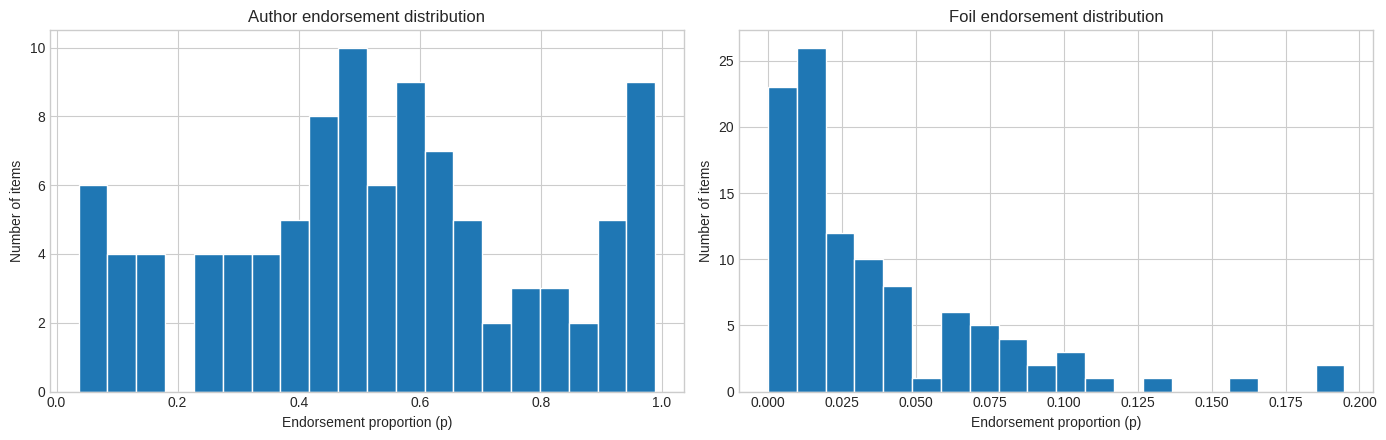

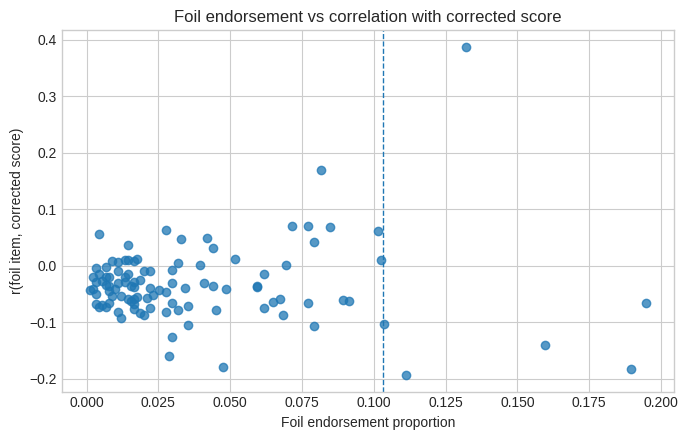

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for i, item_type_name in enumerate(["author", "foil"]):
    sub = item_stats.loc[item_stats["item_type"] == item_type_name, "endorsement_rate"].dropna()
    axes[i].hist(sub, bins=20, edgecolor="white")
    axes[i].set_title(f"{item_type_name.title()} endorsement distribution")
    axes[i].set_xlabel("Endorsement proportion (p)")
    axes[i].set_ylabel("Number of items")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
foil_sub = item_stats.loc[item_stats["item_type"] == "foil"].copy()
ax.scatter(
    foil_sub["endorsement_rate"],
    foil_sub["foil_corr_with_corrected_score"],
    alpha=0.75,
)
ax.axvline(foil_p95, linestyle="--", linewidth=1)
ax.set_title("Foil endorsement vs correlation with corrected score")
ax.set_xlabel("Foil endorsement proportion")
ax.set_ylabel("r(foil item, corrected score)")
plt.tight_layout()
plt.show()

,genre,n_items,mean_endorsement,mean_item_total_r,mean_missing
3,Modern/Literary,33,0.381224,0.429598,0.00000
0,Classics,31,0.615923,0.459515,0.00000
5,Social/Other,14,0.551211,0.561683,0.00000
1,Detective/Thriller,10,0.535096,0.409573,0.00011
2,Fantasy,7,0.666929,0.290231,0.00000
4,Sci-Fi,5,0.739207,0.342215,0.00000


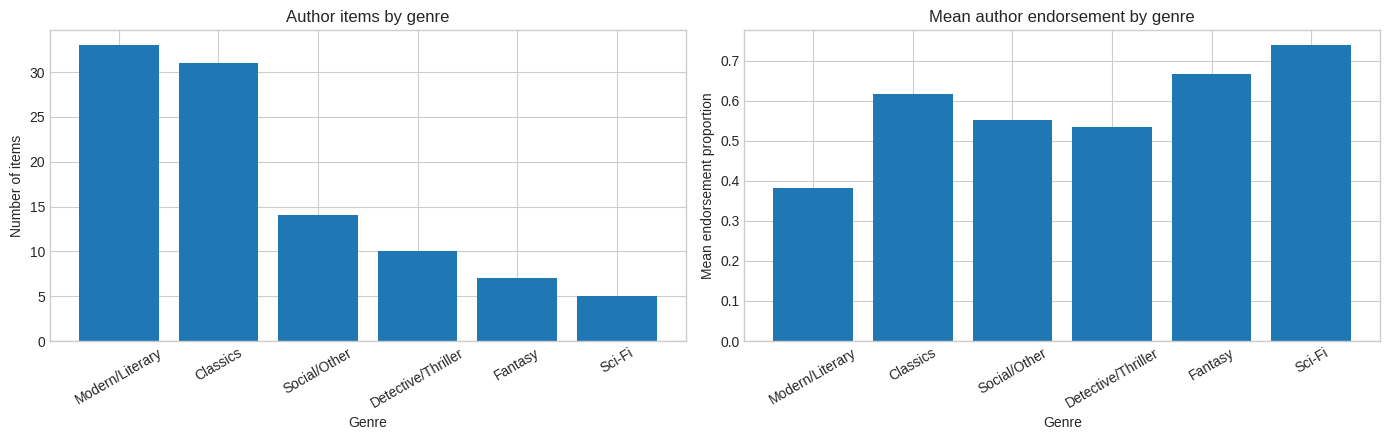

In [10]:
authors_only = item_stats.loc[item_stats["item_type"] == "author"].copy()

genre_counts = (
    authors_only["genre"]
    .value_counts(dropna=False)
    .rename_axis("genre")
    .reset_index(name="n_items")
)

genre_profile = (
    authors_only.groupby("genre", as_index=False)
    .agg(
        n_items=("item_code_norm", "count"),
        mean_endorsement=("endorsement_rate", "mean"),
        mean_item_total_r=("author_corrected_item_total_r", "mean"),
        mean_missing=("missing_rate", "mean"),
    )
    .sort_values("n_items", ascending=False)
)

display(genre_profile)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(genre_counts["genre"], genre_counts["n_items"])
axes[0].set_title("Author items by genre")
axes[0].set_xlabel("Genre")
axes[0].set_ylabel("Number of items")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(genre_profile["genre"], genre_profile["mean_endorsement"])
axes[1].set_title("Mean author endorsement by genre")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Mean endorsement proportion")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 6) Save outputs for downstream review

In [11]:
out_dir = PROJECT_ROOT / "data" / "stepwise_cleaned_versions" / "04_item_level_descriptives"
out_dir.mkdir(parents=True, exist_ok=True)

item_stats_path = out_dir / "ART_pretest_(for Castano)_EN__item_level_descriptives_step05.csv"
flagged_path = out_dir / "ART_pretest_(for Castano)_EN__item_level_descriptives_step05_flagged.csv"
genre_profile_path = out_dir / "ART_pretest_(for Castano)_EN__item_level_descriptives_step05_author_genre_profile.csv"

item_stats.to_csv(item_stats_path, index=False)
flagged_items.to_csv(flagged_path, index=False)
genre_profile.to_csv(genre_profile_path, index=False)

print("Saved outputs:")
print(f"- Full item stats: {item_stats_path}")
print(f"- Flagged items: {flagged_path}")
print(f"- Author genre profile: {genre_profile_path}")

Saved outputs:
- Full item stats: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/04_item_level_descriptives/ART_pretest_(for Castano)_EN__item_level_descriptives_step05.csv
- Flagged items: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/04_item_level_descriptives/ART_pretest_(for Castano)_EN__item_level_descriptives_step05_flagged.csv
- Author genre profile: /home/polina/Documents/Cursor_Projects/Russian Author Recognition Test Cursor/data/stepwise_cleaned_versions/04_item_level_descriptives/ART_pretest_(for Castano)_EN__item_level_descriptives_step05_author_genre_profile.csv
